# Practice 2.2 — Transfer Learning for Cosmetic Product Classification

This notebook trains an ImageNet-pretrained ResNet18 on the local dataset
`data/data_clean_balanced`. It is intentionally saved **without executed outputs**.

**Safety gates:**

- `RUN_TRAINING = False` prevents accidental training.
- `RUN_FINAL_TEST = False` prevents accidental Test evaluation.
- Practice 2.2 writes only to `outputs/practice_2_2`, `reports/practice_2_2`, and
  `runs/practice_2_2`; it does not overwrite the official CIFAR-10 artifacts.
- Validation selects the experiment. Test is evaluated only after checkpoint
  verification passes.


## Phase 1 — Problem Definition

| Item | Definition |
|---|---|
| Task | Supervised, single-label image classification |
| Input | Local JPG product image |
| Classes | Folder names discovered by `torchvision.datasets.ImageFolder` |
| Backbone | ImageNet-pretrained ResNet18 |
| Controlled comparison | E1 `head_only` versus E2 `partial_finetune` |
| Selection metric | Validation Accuracy |
| Final reporting | Test Loss, Accuracy, Macro Precision, Recall and F1 |

The folder contains both original images and files whose names end in
`_augNNN`. All files derived from one original image are treated as one group.
This prevents an original image and its augmented derivative from entering
different splits.


## Phase 2 — Environment Setup

Run the next cell first. It resolves the project root whether Jupyter starts
from `practice_2/` or `practice_2/notebooks/`. No model training or Test
evaluation happens in this cell.


In [1]:
import json
import random
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    path
    for path in (CURRENT_DIR, CURRENT_DIR.parent)
    if (path / "processing_own_phase").is_dir()
)

DATASET_ROOT = PROJECT_ROOT / "data" / "data_clean_balanced"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "practice_2_2"
REPORTS_DIR = PROJECT_ROOT / "reports" / "practice_2_2"
RUNS_DIR = PROJECT_ROOT / "runs" / "practice_2_2"

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3

# Change these only when you intentionally want to run the expensive stages.
RUN_TRAINING = False
RUN_FINAL_TEST = False

assert DATASET_ROOT.is_dir(), f"Dataset directory not found: {DATASET_ROOT}"
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-12

for directory in (OUTPUT_DIR, REPORTS_DIR, RUNS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

environment_table = pd.DataFrame(
    {
        "item": ["Project root", "Dataset", "Device", "Seed", "Training enabled", "Final Test enabled"],
        "value": [PROJECT_ROOT, DATASET_ROOT, DEVICE, SEED, RUN_TRAINING, RUN_FINAL_TEST],
    }
)
display(environment_table)


,item,value
0,Project root,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...
1,Dataset,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...
2,Device,mps
3,Seed,42
4,Training enabled,False
5,Final Test enabled,False


## Phase 3 — Data Inventory and Leakage-Safe Split

The split is determined from file paths and class labels **before transforms
are attached**.

Split policy:

1. Remove `_augNNN` from the filename stem to obtain an original-image group.
2. Split groups independently inside every class using the fixed seed.
3. Train receives originals and pre-generated augmentations belonging to Train groups.
4. Validation and Test receive only original files from their groups.
5. Group sets must be pairwise disjoint.

This is safer than a random file-level split because pre-generated derivatives
cannot leak across Train, Validation, and Test.


In [2]:
raw_dataset = datasets.ImageFolder(DATASET_ROOT, transform=None)
CLASS_NAMES = raw_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
AUGMENTED_PATTERN = re.compile(r"_aug\d+$", flags=re.IGNORECASE)


def is_generated_augmentation(path):
    return AUGMENTED_PATTERN.search(Path(path).stem) is not None


def sample_group(path, label):
    base_stem = AUGMENTED_PATTERN.sub("", Path(path).stem)
    return f"{int(label):02d}/{base_stem}"


records = []
for index, (path, label) in enumerate(raw_dataset.samples):
    records.append(
        {
            "index": index,
            "path": path,
            "label": int(label),
            "class_name": CLASS_NAMES[label],
            "group": sample_group(path, label),
            "is_augmented_file": is_generated_augmentation(path),
        }
    )
records = pd.DataFrame(records)

group_labels = records.groupby("group")["label"].nunique()
assert group_labels.max() == 1, "A source-image group appears under multiple class labels."

rng = np.random.default_rng(SEED)
train_groups, val_groups, test_groups = set(), set(), set()

for class_id in range(NUM_CLASSES):
    groups = np.array(
        sorted(records.loc[records["label"] == class_id, "group"].unique()),
        dtype=object,
    )
    rng.shuffle(groups)
    n_groups = len(groups)
    n_val = round(n_groups * VAL_RATIO)
    n_test = round(n_groups * TEST_RATIO)
    n_train = n_groups - n_val - n_test
    assert min(n_train, n_val, n_test) > 0

    train_groups.update(groups[:n_train])
    val_groups.update(groups[n_train:n_train + n_val])
    test_groups.update(groups[n_train + n_val:])

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

train_indices = records.loc[records["group"].isin(train_groups), "index"].tolist()
val_indices = records.loc[
    records["group"].isin(val_groups) & ~records["is_augmented_file"], "index"
].tolist()
test_indices = records.loc[
    records["group"].isin(test_groups) & ~records["is_augmented_file"], "index"
].tolist()

assert not records.loc[records["index"].isin(val_indices), "is_augmented_file"].any()
assert not records.loc[records["index"].isin(test_indices), "is_augmented_file"].any()
assert set(train_indices).isdisjoint(val_indices)
assert set(train_indices).isdisjoint(test_indices)
assert set(val_indices).isdisjoint(test_indices)

split_groups = {
    "Train": train_groups,
    "Validation": val_groups,
    "Test": test_groups,
}
split_indices = {
    "Train": train_indices,
    "Validation": val_indices,
    "Test": test_indices,
}

split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "source_groups": len(split_groups[split_name]),
            "files_used": len(split_indices[split_name]),
            "generated_augmentations_used": int(
                records.loc[
                    records["index"].isin(split_indices[split_name]),
                    "is_augmented_file",
                ].sum()
            ),
        }
        for split_name in ("Train", "Validation", "Test")
    ]
)

dataset_summary = pd.DataFrame(
    {
        "item": ["Dataset type", "Classes", "Files discovered", "Original groups", "Generated files"],
        "value": [
            "Local ImageFolder",
            NUM_CLASSES,
            len(records),
            records["group"].nunique(),
            int(records["is_augmented_file"].sum()),
        ],
    }
)
display(dataset_summary)
display(split_summary)


,item,value
0,Dataset type,Local ImageFolder
1,Classes,10
2,Files discovered,3202
3,Original groups,2896
4,Generated files,306


,split,source_groups,files_used,generated_augmentations_used
0,Train,2028,2226,198
1,Validation,434,434,0
2,Test,434,434,0


## Phase 4 — Exploratory Data Analysis

EDA uses Train records only for sample visualization. The distribution table
may count locked Validation/Test labels as a structural integrity check, but no
Test metric or image is used for model selection.


split,Test,Train,Validation
class_name,,,
body_wash,45,224,45
face_mask,45,220,45
facial_cleanser,48,226,48
lipstick,43,220,43
moisturizer,34,220,34
perfume,43,220,43
serum,45,225,45
shampoo,41,225,41
sunscreen,48,224,48


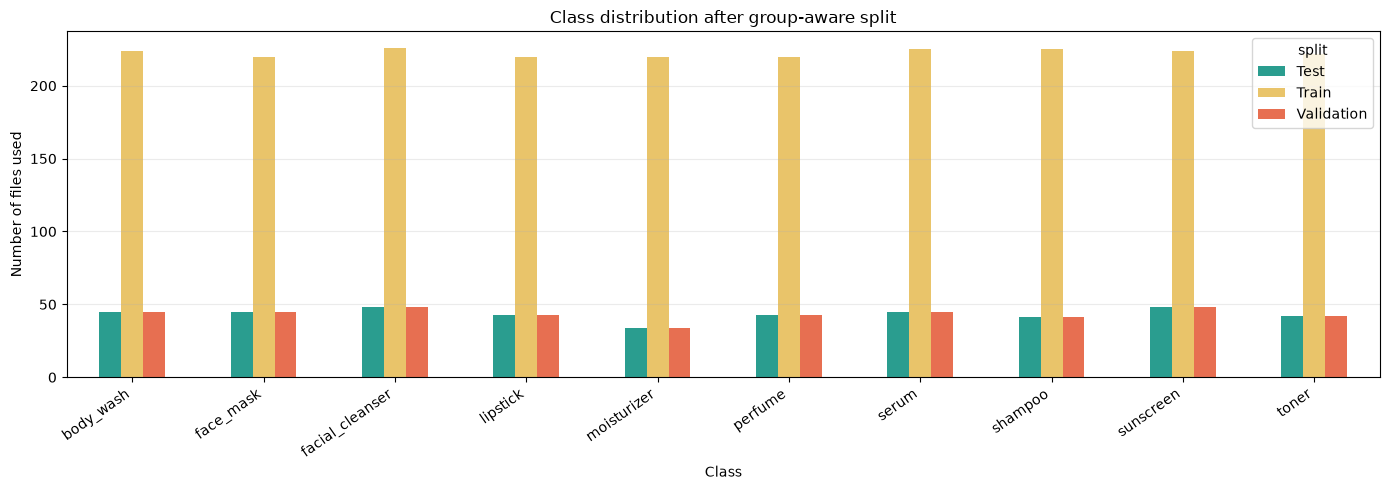

In [3]:
distribution_rows = []
for split_name, indices in split_indices.items():
    counts = (
        records.loc[records["index"].isin(indices), "class_name"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    )
    for class_name, count in counts.items():
        distribution_rows.append(
            {"split": split_name, "class_name": class_name, "samples": int(count)}
        )

class_distribution = pd.DataFrame(distribution_rows).pivot(
    index="class_name", columns="split", values="samples"
).reindex(CLASS_NAMES)
class_distribution.loc["Total"] = class_distribution.sum(axis=0)
display(class_distribution.style.background_gradient(cmap="YlGnBu", axis=0))

plot_distribution = class_distribution.drop(index="Total")
ax = plot_distribution.plot(kind="bar", figsize=(14, 5), color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_title("Class distribution after group-aware split")
ax.set_xlabel("Class")
ax.set_ylabel("Number of files used")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


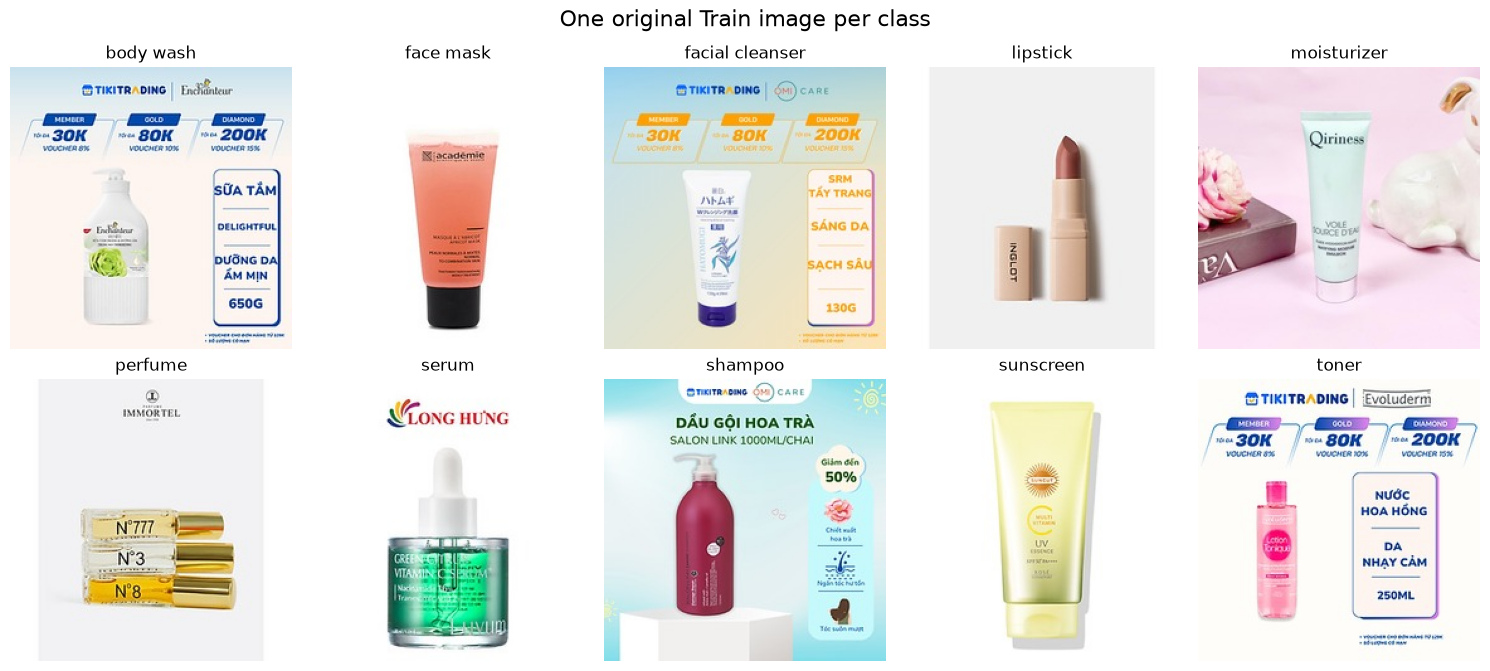

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for class_id, ax in enumerate(axes.flat):
    candidate = records[
        (records["label"] == class_id)
        & (records["group"].isin(train_groups))
        & (~records["is_augmented_file"])
    ].iloc[0]
    image, _ = raw_dataset[int(candidate["index"])]
    ax.imshow(image)
    ax.set_title(CLASS_NAMES[class_id].replace("_", " "))
    ax.axis("off")
fig.suptitle("One original Train image per class", fontsize=16)
plt.tight_layout()
plt.show()


## Phase 5 — Preprocessing

Transforms are lazy: they execute only when a sample is requested. Split
membership has already been fixed in Phase 3.

- Train: random resized crop, horizontal flip and color jitter.
- Validation/Test: deterministic resize and center crop.
- All splits: ImageNet normalization expected by pretrained ResNet18.


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)
evaluation_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

# Separate transform-bearing dataset objects prevent transform sharing.
train_dataset_view = datasets.ImageFolder(DATASET_ROOT, transform=train_transform)
validation_dataset_view = datasets.ImageFolder(DATASET_ROOT, transform=evaluation_transform)
test_dataset_view = datasets.ImageFolder(DATASET_ROOT, transform=evaluation_transform)

train_dataset = Subset(train_dataset_view, train_indices)
validation_dataset = Subset(validation_dataset_view, val_indices)
test_dataset = Subset(test_dataset_view, test_indices)

assert train_dataset.dataset is not validation_dataset.dataset
assert validation_dataset.dataset is not test_dataset.dataset
assert train_dataset.dataset.classes == validation_dataset.dataset.classes == test_dataset.dataset.classes
assert "RandomResizedCrop" in repr(train_transform)
assert "RandomHorizontalFlip" in repr(train_transform)
assert "ColorJitter" in repr(train_transform)
assert "Random" not in repr(evaluation_transform)
assert repr(validation_dataset.dataset.transform) == repr(test_dataset.dataset.transform)


def make_train_val_loaders(seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    common = {
        "batch_size": BATCH_SIZE,
        "num_workers": 0,
        "pin_memory": DEVICE.type == "cuda",
    }
    return (
        DataLoader(train_dataset, shuffle=True, generator=generator, **common),
        DataLoader(validation_dataset, shuffle=False, **common),
    )


transform_table = pd.DataFrame(
    [
        {"split": "Train", "random_augmentation": True, "files": len(train_dataset)},
        {"split": "Validation", "random_augmentation": False, "files": len(validation_dataset)},
        {"split": "Test", "random_augmentation": False, "files": len(test_dataset)},
    ]
)
display(transform_table.style.background_gradient(cmap="PuBu", subset=["files"]))
print("Train transform:\n", train_transform)
print("\nValidation/Test transform:\n", evaluation_transform)


,split,random_augmentation,files
0,Train,True,2226
1,Validation,False,434
2,Test,False,434


Train transform:
 Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transform:
 Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Phase 6 — Model Building and Sanity Check

The classifier head is replaced with `NUM_CLASSES` outputs discovered from the
folder names. This cell may download pretrained ResNet18 weights if they are
not already present in the local Torch cache; it does not train the model.


In [6]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from processing_own_phase.model import build_model

baseline_model = build_model(
    model_name="resnet18",
    training_mode="head_only",
    num_classes=NUM_CLASSES,
).to(DEVICE)

sample_images, sample_labels = next(iter(make_train_val_loaders()[0]))
with torch.inference_mode():
    sample_logits = baseline_model(sample_images[:4].to(DEVICE))

assert sample_logits.shape == (4, NUM_CLASSES)
model_table = pd.DataFrame(
    {
        "item": ["Backbone", "Strategy", "Classes", "Output shape", "Total parameters", "Trainable parameters"],
        "value": [
            "ResNet18",
            "head_only",
            NUM_CLASSES,
            tuple(sample_logits.shape),
            sum(p.numel() for p in baseline_model.parameters()),
            sum(p.numel() for p in baseline_model.parameters() if p.requires_grad),
        ],
    }
)
display(model_table)
del baseline_model, sample_images, sample_labels, sample_logits
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


,item,value
0,Backbone,ResNet18
1,Strategy,head_only
2,Classes,10
3,Output shape,"(4, 10)"
4,Total parameters,11181642
5,Trainable parameters,5130


## Phase 7 — Training Protocol

Every epoch records Train Loss/Accuracy, Validation Loss/Accuracy, learning
rate and epoch time. Best checkpoint and Early Stopping use Validation only.
The Test DataLoader is deliberately not constructed in the training phase.


In [7]:
from processing_own_phase.train import train_model

CONTROLLED_BASE_CONFIG = {
    "model_name": "resnet18",
    "optimizer": "Adam",
    "scheduler": "ReduceLROnPlateau",
    "learning_rate": 1e-3,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "weight_decay": 1e-4,
    "image_size": IMAGE_SIZE,
    "seed": SEED,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "best_model_metric": "val_acc",
    "grad_clip": 1.0,
    "num_classes": NUM_CLASSES,
}

EXPERIMENTS_2_2 = {
    "E1_head_only": {
        **CONTROLLED_BASE_CONFIG,
        "training_mode": "head_only",
    },
    "E2_partial_finetune": {
        **CONTROLLED_BASE_CONFIG,
        "training_mode": "partial_finetune",
    },
}

comparison_fields = [key for key in CONTROLLED_BASE_CONFIG]
for field in comparison_fields:
    assert EXPERIMENTS_2_2["E1_head_only"][field] == EXPERIMENTS_2_2["E2_partial_finetune"][field]
assert EXPERIMENTS_2_2["E1_head_only"]["training_mode"] != EXPERIMENTS_2_2["E2_partial_finetune"]["training_mode"]

display(pd.DataFrame(EXPERIMENTS_2_2).T)


,model_name,optimizer,scheduler,learning_rate,batch_size,epochs,weight_decay,image_size,seed,early_stopping_patience,best_model_metric,grad_clip,num_classes,training_mode
E1_head_only,resnet18,Adam,ReduceLROnPlateau,0.001,32,10,0.0001,224,42,3,val_acc,1.0,10,head_only
E2_partial_finetune,resnet18,Adam,ReduceLROnPlateau,0.001,32,10,0.0001,224,42,3,val_acc,1.0,10,partial_finetune


## Phase 8 — Controlled E1/E2 Training

Before running the next cell intentionally:

1. Confirm the split and transform assertions above passed.
2. Change `RUN_TRAINING = True` in Phase 2 and rerun that cell.
3. Run the training cell once.

Both experiments receive a freshly seeded DataLoader and identically
initialized pretrained model. Only the fine-tuning strategy changes.


In [8]:
HISTORY_PATH = OUTPUT_DIR / "controlled_training_history.json"
COMPARISON_PATH = OUTPUT_DIR / "controlled_experiment_comparison.csv"
SELECTION_PATH = OUTPUT_DIR / "controlled_experiment_selection.json"

if not RUN_TRAINING:
    display(Markdown("**Training skipped.** Set `RUN_TRAINING = True` in Phase 2 when ready."))
else:
    histories = {}
    comparison_rows = []

    for experiment_name, experiment_config in EXPERIMENTS_2_2.items():
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)

        train_loader, validation_loader = make_train_val_loaders(SEED)
        run_dir = RUNS_DIR / experiment_name
        config = {
            **experiment_config,
            "output_dir": str(run_dir),
        }
        model = build_model(
            model_name=config["model_name"],
            training_mode=config["training_mode"],
            num_classes=NUM_CLASSES,
        ).to(DEVICE)

        started = time.perf_counter()
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=validation_loader,
            config=config,
            device=DEVICE,
        )
        training_time = time.perf_counter() - started
        histories[experiment_name] = history
        best_index = int(history["best_epoch"]) - 1

        comparison_rows.append(
            {
                "experiment": experiment_name,
                "strategy": config["training_mode"],
                "epochs_trained": len(history["epoch"]),
                "best_epoch": int(history["best_epoch"]),
                "best_val_accuracy": float(history["val_acc"][best_index]),
                "best_val_loss": float(history["val_loss"][best_index]),
                "training_time_seconds": float(training_time),
                "early_stopping_triggered": bool(history["stopped_early"]),
                "checkpoint": str(run_dir / "best.pt"),
            }
        )
        del model, train_loader, validation_loader
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    comparison = pd.DataFrame(comparison_rows).sort_values(
        "best_val_accuracy", ascending=False
    ).reset_index(drop=True)
    selected = comparison.iloc[0]
    selection = {
        "selection_metric": "val_accuracy",
        "selection_source": "validation_only",
        "test_data_used": False,
        "selected_experiment": selected["experiment"],
        "strategy": selected["strategy"],
        "best_epoch": int(selected["best_epoch"]),
        "best_val_accuracy": float(selected["best_val_accuracy"]),
        "best_val_loss": float(selected["best_val_loss"]),
        "checkpoint": selected["checkpoint"],
        "class_names": CLASS_NAMES,
    }

    HISTORY_PATH.write_text(json.dumps(histories, indent=2))
    comparison.to_csv(COMPARISON_PATH, index=False)
    SELECTION_PATH.write_text(json.dumps(selection, indent=2))
    display(comparison)
    display(selection)


**Training skipped.** Set `RUN_TRAINING = True` in Phase 2 when ready.

## Phase 8b — Improved E3/E4 Training (Mixup/CutMix + EMA + WarmupCosine)

This phase trains two more controlled experiments that share the same
controlled variables as E1/E2 but add four anti-overfitting mechanisms:

1. Stronger data augmentation (RandAugment-style + rotation + affine).
2. **Mixup / CutMix** label-preserving image mixing on every batch.
3. **EMA** (Exponential Moving Average) of model weights; EMA model is used
   for validation-based selection and final Test reporting.
4. **WarmupCosine** scheduler instead of ``ReduceLROnPlateau``.

Re-run this cell only after Phase 8 has produced
``controlled_training_history.json`` (so the dataset and manifest are in
place). The improved runs are written to a *separate* staging directory so
they never overwrite the E1/E2 baseline artifacts.


In [ ]:
IMPROVED_OUTPUT_DIR = OUTPUT_DIR / "improved"
IMPROVED_RUNS_DIR = RUNS_DIR / "improved"
IMPROVED_RUNS_DIR.mkdir(parents=True, exist_ok=True)
IMPROVED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMPROVED_BASE_CONFIG = {
    "model_name": "resnet18",
    "optimizer": "AdamW",
    "scheduler": "WarmupCosine",
    "learning_rate": 1e-3,
    "head_learning_rate": 1e-3,
    "backbone_learning_rate": 1e-4,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "weight_decay": 2e-4,
    "image_size": IMAGE_SIZE,
    "seed": SEED,
    "early_stopping_patience": 4,
    "best_model_metric": "val_acc",
    "early_stopping_metric": "val_loss",
    "scheduler_metric": "val_loss",
    "label_smoothing": 0.10,
    "dropout": 0.30,
    "random_erasing_probability": 0.25,
    "grad_clip": 1.0,
    "num_classes": NUM_CLASSES,
    "selection_source": "validation_only",
    "test_data_used": False,
    # Improved-only knobs:
    "augment_strength": "strong",
    "mixup_alpha": 0.20,
    "cutmix_alpha": 1.00,
    "cutmix_prob": 0.50,
    "use_ema": True,
    "ema_decay": 0.999,
    "warmup_epochs": 2,
    "min_lr_ratio": 0.01,
    "report_metric": "val_acc",
}

IMPROVED_EXPERIMENTS = {
    "E3_resnet18_head_improved": {
        **IMPROVED_BASE_CONFIG,
        "training_mode": "head_only",
    },
    "E4_resnet18_partial_improved": {
        **IMPROVED_BASE_CONFIG,
        "training_mode": "partial_finetune",
    },
}

for field in IMPROVED_BASE_CONFIG:
    e3 = IMPROVED_EXPERIMENTS["E3_resnet18_head_improved"][field]
    e4 = IMPROVED_EXPERIMENTS["E4_resnet18_partial_improved"][field]
    assert e3 == e4, f"E3/E4 must agree on {field}; got {e3} vs {e4}"
assert (
    IMPROVED_EXPERIMENTS["E3_resnet18_head_improved"]["training_mode"]
    != IMPROVED_EXPERIMENTS["E4_resnet18_partial_improved"]["training_mode"]
)
display(pd.DataFrame(IMPROVED_EXPERIMENTS).T)

# Locate the manifest Phase 3 already produced.
SPLIT_MANIFEST_CSV = OUTPUT_DIR / "split_manifest.csv"
assert SPLIT_MANIFEST_CSV.exists(), (
    "Phase 3 must have produced split_manifest.csv before improved training."
)

from processing_own_phase.train_practice_2_2_improved import (
    run_improved_training,
)

IMPROVED_HISTORY_PATH = IMPROVED_OUTPUT_DIR / "improved_training_history.json"
IMPROVED_COMPARISON_PATH = IMPROVED_OUTPUT_DIR / "improved_experiment_comparison.csv"
IMPROVED_SELECTION_PATH = IMPROVED_OUTPUT_DIR / "improved_experiment_selection.json"

if not RUN_TRAINING:
    display(Markdown(
        "**Improved training skipped.** Set `RUN_TRAINING = True` in Phase 2 to "
        "execute E3/E4."
    ))
else:
    improved_bundle = run_improved_training(
        dataset_root=DATASET_ROOT,
        manifest_path=SPLIT_MANIFEST_CSV,
        staging_root=IMPROVED_RUNS_DIR,
        device=DEVICE,
    )
    improved_results = improved_bundle["results"]
    improved_selection = improved_bundle["selection"]
    IMPROVED_HISTORY_PATH.write_text(json.dumps(
        {row["experiment"]: json.loads(
            (IMPROVED_RUNS_DIR / "runs" / row["experiment"] / "history.json").read_text()
        ) for row in improved_results},
        indent=2,
        default=str,
    ))
    improved_comparison = pd.DataFrame(improved_results)
    improved_comparison.to_csv(IMPROVED_COMPARISON_PATH, index=False)
    IMPROVED_SELECTION_PATH.write_text(json.dumps(improved_selection, indent=2))
    display(improved_comparison)
    display(Markdown(
        f"**Improved winner:** `{improved_selection['selected_experiment']}` "
        f"with Val Accuracy = **{improved_selection['best_val_accuracy']:.4f}**, "
        f"Val Macro F1 = **{improved_selection['best_val_macro_f1']:.4f}**."
    ))


## Phase 9b — Baseline vs Improved Comparison

This phase compares the E1/E2 baseline against the E3/E4 improved runs side
by side on Validation-only metrics. **No Test access happens here.**


In [ ]:
if not IMPROVED_SELECTION_PATH.exists():
    display(Markdown(
        "**No improved artifacts yet.** Run Phase 8b first."
    ))
else:
    baseline_selection = json.loads(SELECTION_PATH.read_text())
    improved_selection = json.loads(IMPROVED_SELECTION_PATH.read_text())
    baseline_comparison = pd.read_csv(COMPARISON_PATH)
    improved_comparison = pd.read_csv(IMPROVED_COMPARISON_PATH)

    summary_rows = []
    for label, comparison_df, sel in (
        ("Baseline", baseline_comparison, baseline_selection),
        ("Improved", improved_comparison, improved_selection),
    ):
        summary_rows.append({
            "track": label,
            "selected_experiment": sel["selected_experiment"],
            "strategy": sel["selected_experiment"],
            "best_val_accuracy": sel["best_val_accuracy"],
            "best_val_loss": sel["best_val_loss"],
            "best_val_macro_f1": sel["best_val_macro_f1"],
            "epochs_trained": sel["epochs_trained"],
            "early_stopping_triggered": sel["early_stopping_triggered"],
        })
    summary = pd.DataFrame(summary_rows)
    display(summary)

    delta_acc = (
        improved_selection["best_val_accuracy"]
        - baseline_selection["best_val_accuracy"]
    )
    delta_f1 = (
        improved_selection["best_val_macro_f1"]
        - baseline_selection.get("best_val_macro_f1", 0.0)
    )
    display(Markdown(
        f"**Δ Val Accuracy (improved − baseline):** "
        f"`{delta_acc:+.4f}`  \n"
        f"**Δ Val Macro F1 (improved − baseline):** "
        f"`{delta_f1:+.4f}`"
    ))

    # Plot Train vs Val loss for both tracks side-by-side.
    baseline_histories = json.loads(HISTORY_PATH.read_text())
    improved_histories = json.loads(IMPROVED_HISTORY_PATH.read_text())
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for exp_name, history in baseline_histories.items():
        axes[0].plot(history["epoch"], history["train_loss"],
                     linestyle="--", label=f"{exp_name} train")
        axes[0].plot(history["epoch"], history["val_loss"],
                     label=f"{exp_name} val")
    for exp_name, history in improved_histories.items():
        axes[1].plot(history["epoch"], history["train_loss"],
                     linestyle="--", label=f"{exp_name} train")
        axes[1].plot(history["epoch"], history["val_loss"],
                     label=f"{exp_name} val")
    axes[0].set(title="Baseline (E1/E2)", xlabel="Epoch", ylabel="Loss")
    axes[1].set(title="Improved (E3/E4)", xlabel="Epoch", ylabel="Loss")
    for ax in axes:
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMPROVED_OUTPUT_DIR / "baseline_vs_improved_loss.png", dpi=120)
    plt.show()


## Phase 9 — Learning Curves and Validation-Only Selection

This cell reads saved artifacts. It never evaluates Test. Run it after E1/E2
training finishes.


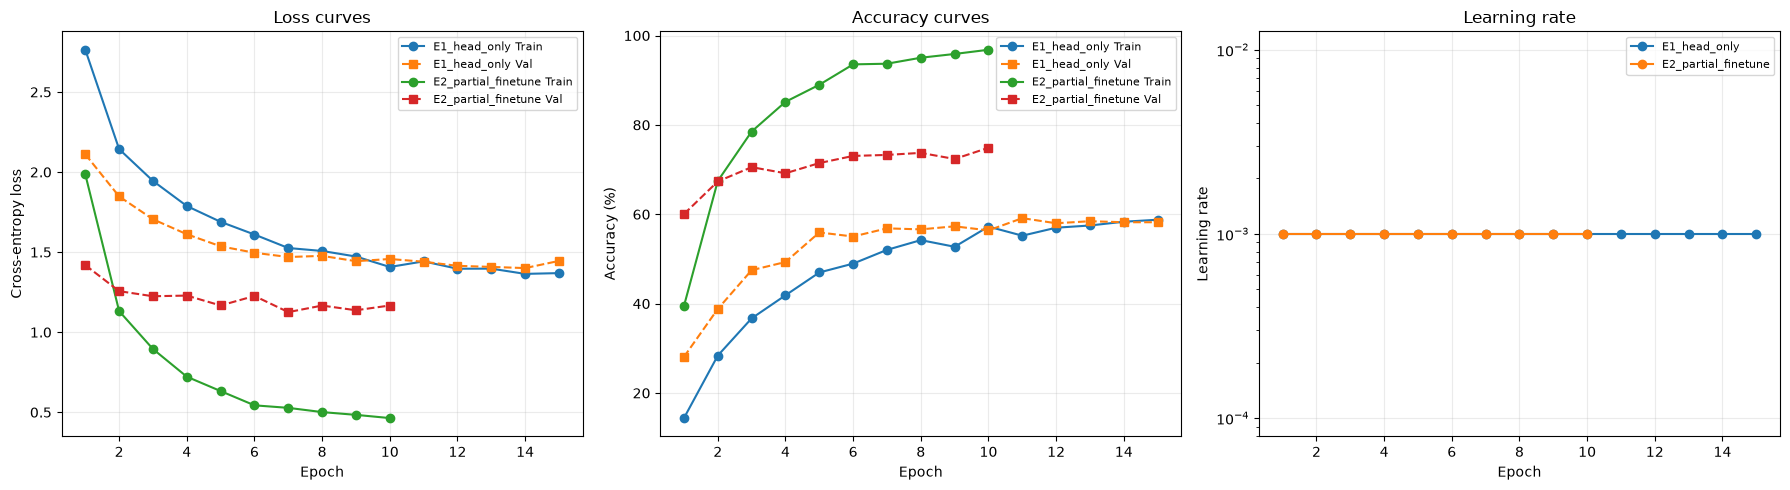

AssertionError: 

In [10]:
if not (HISTORY_PATH.exists() and COMPARISON_PATH.exists() and SELECTION_PATH.exists()):
    display(Markdown("**No Practice 2.2 training artifacts yet.** Complete Phase 8 first."))
else:
    histories = json.loads(HISTORY_PATH.read_text())
    comparison = pd.read_csv(COMPARISON_PATH)
    selection = json.loads(SELECTION_PATH.read_text())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for experiment_name, history in histories.items():
        epochs = history["epoch"]
        axes[0].plot(epochs, history["train_loss"], marker="o", label=f"{experiment_name} Train")
        axes[0].plot(epochs, history["val_loss"], marker="s", linestyle="--", label=f"{experiment_name} Val")
        axes[1].plot(epochs, history["train_acc"], marker="o", label=f"{experiment_name} Train")
        axes[1].plot(epochs, history["val_acc"], marker="s", linestyle="--", label=f"{experiment_name} Val")
        axes[2].plot(epochs, history["lr"], marker="o", label=experiment_name)

    axes[0].set(title="Loss curves", xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[1].set(title="Accuracy curves", xlabel="Epoch", ylabel="Accuracy (%)")
    axes[2].set(title="Learning rate", xlabel="Epoch", ylabel="Learning rate")
    axes[2].set_yscale("log")
    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    plt.tight_layout()
    curve_path = REPORTS_DIR / "controlled_training_curves.png"
    plt.savefig(curve_path, dpi=150, bbox_inches="tight")
    plt.show()

    assert selection["selection_source"] == "validation_only"
    assert selection["test_data_used"] is False
    assert not any(column.lower().startswith("test") for column in comparison.columns)
    display(comparison.style.background_gradient(cmap="YlGnBu", subset=["best_val_accuracy"]))
    display(pd.DataFrame([selection]))


## Phase 10 — Reload and Verify the Selected Checkpoint

The best checkpoint is rebuilt and evaluated on Validation. Test remains
locked. A mismatch raises an exception and blocks final evaluation.


In [ ]:
from processing_own_phase.train import evaluate as evaluate_percent

VERIFICATION_PATH = OUTPUT_DIR / "validation_verification.json"

if not SELECTION_PATH.exists():
    display(Markdown("**Checkpoint verification skipped.** Complete Phase 8 first."))
else:
    selection = json.loads(SELECTION_PATH.read_text())
    checkpoint_path = Path(selection["checkpoint"])
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Selected checkpoint not found: {checkpoint_path}")

    verified_model = build_model(
        model_name="resnet18",
        training_mode=selection["strategy"],
        num_classes=NUM_CLASSES,
    ).to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    verified_model.load_state_dict(checkpoint["model_state_dict"])

    _, validation_loader = make_train_val_loaders(SEED)
    validation_loss, validation_accuracy = evaluate_percent(
        verified_model,
        validation_loader,
        nn.CrossEntropyLoss(),
        DEVICE,
    )
    delta = abs(validation_accuracy - float(selection["best_val_accuracy"]))
    if delta > 1e-6:
        raise RuntimeError(
            "Validation verification failed: "
            f"recorded={selection['best_val_accuracy']:.8f}, "
            f"reloaded={validation_accuracy:.8f}, delta={delta:.8f}"
        )

    verification = {
        "status": "PASS",
        "checkpoint": str(checkpoint_path),
        "selection_source": "validation_only",
        "recorded_val_accuracy": float(selection["best_val_accuracy"]),
        "verified_val_accuracy": float(validation_accuracy),
        "validation_loss": float(validation_loss),
        "accuracy_delta": float(delta),
        "test_accessed": False,
    }
    VERIFICATION_PATH.write_text(json.dumps(verification, indent=2))
    display(pd.DataFrame([verification]))


## Phase 11b — Final Test Evaluation on Improved Checkpoint

Run only after Phase 11 (baseline final test) displays `PASS`. This cell
reuses ``regenerate_final_artifacts`` but targets the **improved** selection
artifact so the Test set is evaluated exactly once for the improved winner.


In [ ]:
IMPROVED_TEST_OUTPUT_DIR = IMPROVED_OUTPUT_DIR / "final_test"
IMPROVED_REPORTS_DIR = REPORTS_DIR / "improved"
IMPROVED_TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMPROVED_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

if not IMPROVED_SELECTION_PATH.exists():
    raise RuntimeError("Phase 8b must run before Phase 11b.")
if not SUMMARY_PATH.exists():
    display(Markdown(
        "**Run Phase 11 first to confirm the Test pipeline works for the "
        "baseline, then re-run this cell.**"
    ))
else:
    from processing_own_phase.final_evaluate import regenerate_final_artifacts

    improved_summary = regenerate_final_artifacts(
        selection_path=str(IMPROVED_SELECTION_PATH),
        output_dir=str(IMPROVED_TEST_OUTPUT_DIR),
        reports_dir=str(IMPROVED_REPORTS_DIR),
        batch_size=BATCH_SIZE,
        validation_tolerance=1e-6,
        device=DEVICE,
    )
    display(Markdown("### Improved Final Test Results"))
    display(pd.DataFrame([{
        k: improved_summary[k]
        for k in (
            "selected_experiment",
            "test_accuracy",
            "test_loss",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "test_samples",
        )
    }]))

    baseline_summary = json.loads(SUMMARY_PATH.read_text())
    delta = {
        "metric": [
            "test_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
        ],
        "baseline": [
            baseline_summary["test_accuracy"],
            baseline_summary["macro_precision"],
            baseline_summary["macro_recall"],
            baseline_summary["macro_f1"],
        ],
        "improved": [
            improved_summary["test_accuracy"],
            improved_summary["macro_precision"],
            improved_summary["macro_recall"],
            improved_summary["macro_f1"],
        ],
    }
    delta["delta"] = [
        improved_summary[k] - baseline_summary[k]
        for k in delta["metric"]
    ]
    display(pd.DataFrame(delta))


## Phase 11 — Final Test Evaluation and Error Analysis

Run this phase only after Phase 10 displays `PASS`.

To prevent accidental repeated Test evaluation, the cell refuses to run if
`outputs/practice_2_2/summary.json` already exists. Test is used for reporting,
never for choosing E1/E2 or selecting an epoch.


In [ ]:
from processing_own_phase.evaluate import (
    compute_classification_metrics,
    evaluate as evaluate_fraction,
)

SUMMARY_PATH = OUTPUT_DIR / "summary.json"

if not RUN_FINAL_TEST:
    display(Markdown("**Final Test skipped.** Set `RUN_FINAL_TEST = True` only after Validation Verification PASS."))
else:
    if not VERIFICATION_PATH.exists():
        raise RuntimeError("Run checkpoint verification before Final Test.")
    verification = json.loads(VERIFICATION_PATH.read_text())
    if verification.get("status") != "PASS" or verification.get("test_accessed") is not False:
        raise RuntimeError("Final Test is blocked because checkpoint verification did not pass cleanly.")
    if SUMMARY_PATH.exists():
        raise RuntimeError(
            f"Final Test has already been recorded at {SUMMARY_PATH}. "
            "Do not evaluate it repeatedly."
        )

    selection = json.loads(SELECTION_PATH.read_text())
    checkpoint_path = Path(selection["checkpoint"])
    final_model = build_model(
        model_name="resnet18",
        training_mode=selection["strategy"],
        num_classes=NUM_CLASSES,
    ).to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    final_model.load_state_dict(checkpoint["model_state_dict"])

    # Construct the Test DataLoader only after verification has passed.
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=DEVICE.type == "cuda",
    )
    test_result = evaluate_fraction(
        final_model,
        test_loader,
        nn.CrossEntropyLoss(),
        DEVICE,
    )
    metrics = compute_classification_metrics(
        test_result["predictions"],
        test_result["labels"],
        NUM_CLASSES,
        CLASS_NAMES,
    )

    confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    for true_label, predicted_label in zip(test_result["labels"], test_result["predictions"]):
        confusion[int(true_label), int(predicted_label)] += 1
    assert confusion.sum() == len(test_dataset)
    assert abs(np.trace(confusion) / confusion.sum() - test_result["accuracy"]) < 1e-12

    probabilities = test_result["probabilities"]
    predictions = test_result["predictions"]
    labels = test_result["labels"]
    prediction_paths = [test_dataset_view.samples[index][0] for index in test_indices]
    prediction_table = pd.DataFrame(
        {
            "path": prediction_paths,
            "true_label_id": labels,
            "true_label": [CLASS_NAMES[int(x)] for x in labels],
            "predicted_label_id": predictions,
            "predicted_label": [CLASS_NAMES[int(x)] for x in predictions],
            "confidence": probabilities.max(axis=1),
            "is_correct": predictions == labels,
        }
    )
    prediction_table.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
    pd.DataFrame(confusion, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        OUTPUT_DIR / "confusion_matrix.csv"
    )

    report_rows = []
    for class_name, values in metrics["per_class"].items():
        report_rows.append({"class": class_name, **values})
    pd.DataFrame(report_rows).to_csv(OUTPUT_DIR / "classification_report.csv", index=False)

    summary = {
        "validation_verification": "PASS",
        "selection_source": "validation_only",
        "selected_experiment": selection["selected_experiment"],
        "checkpoint": str(checkpoint_path),
        "test_accuracy": float(test_result["accuracy"]),
        "test_loss": float(test_result["loss"]),
        "macro_precision": float(metrics["macro_avg"]["precision"]),
        "macro_recall": float(metrics["macro_avg"]["recall"]),
        "macro_f1": float(metrics["macro_avg"]["f1-score"]),
        "test_samples": int(len(test_dataset)),
        "test_evaluation_count": 1,
        "class_names": CLASS_NAMES,
    }
    SUMMARY_PATH.write_text(json.dumps(summary, indent=2))
    display(pd.DataFrame([summary]))


In [ ]:
if not SUMMARY_PATH.exists():
    display(Markdown("**No Final Test artifacts yet.** Run the guarded Final Test cell once when ready."))
else:
    summary = json.loads(SUMMARY_PATH.read_text())
    confusion = pd.read_csv(OUTPUT_DIR / "confusion_matrix.csv", index_col=0)
    predictions_table = pd.read_csv(OUTPUT_DIR / "predictions.csv")

    assert int(confusion.to_numpy().sum()) == int(summary["test_samples"])
    confusion_accuracy = np.trace(confusion.to_numpy()) / confusion.to_numpy().sum()
    assert abs(confusion_accuracy - float(summary["test_accuracy"])) < 1e-12
    assert len(predictions_table) == int(summary["test_samples"])

    final_metrics = pd.DataFrame(
        {
            "Metric": ["Test Accuracy", "Test Loss", "Macro Precision", "Macro Recall", "Macro F1", "Test Samples"],
            "Value": [
                summary["test_accuracy"],
                summary["test_loss"],
                summary["macro_precision"],
                summary["macro_recall"],
                summary["macro_f1"],
                summary["test_samples"],
            ],
        }
    )
    display(final_metrics.style.background_gradient(cmap="YlGnBu", subset=["Value"]))

    raw = confusion.to_numpy()
    normalized = raw / np.maximum(raw.sum(axis=1, keepdims=True), 1)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(raw, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    sns.heatmap(normalized, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[0].set_title("Raw confusion matrix (sample counts)")
    axes[1].set_title("Row-normalized confusion matrix (per-class recall)")
    for ax in axes:
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.tick_params(axis="x", rotation=40)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()


In [ ]:
if SUMMARY_PATH.exists():
    predictions_table = pd.read_csv(OUTPUT_DIR / "predictions.csv")
    correct = predictions_table[predictions_table["is_correct"] == True].sort_values("confidence", ascending=False)
    incorrect = predictions_table[predictions_table["is_correct"] == False].sort_values("confidence", ascending=False)
    selected_rows = pd.concat([correct.head(10), incorrect.head(10)], ignore_index=True)

    fig, axes = plt.subplots(4, 5, figsize=(16, 13))
    for ax, (_, row) in zip(axes.flat, selected_rows.iterrows()):
        image = plt.imread(row["path"])
        ax.imshow(image)
        color = "#2a9d8f" if bool(row["is_correct"]) else "#e63946"
        ax.set_title(
            f"T: {str(row['true_label']).replace('_', ' ')}\n"
            f"P: {str(row['predicted_label']).replace('_', ' ')} ({row['confidence']:.2f})",
            fontsize=9,
            color=color,
        )
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes.flat[len(selected_rows):]:
        ax.axis("off")
    fig.suptitle("Prediction grid: correct (green) and incorrect (red)", fontsize=16)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "prediction_grid_mixed.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    display(Markdown("Prediction grid will appear after the guarded Final Test is completed."))


## Phase 12 — Reproducibility, Limitations and Conclusion

### Reproducibility checklist

- Fixed seed: 42.
- Group-aware stratified Train/Validation/Test split before preprocessing.
- No pre-generated `_augNNN` file in Validation or Test.
- Separate transform-bearing dataset objects.
- Identical E1/E2 base configuration; only fine-tuning strategy differs.
- Validation-only experiment selection and best-checkpoint selection.
- Reloaded checkpoint must reproduce recorded Validation Accuracy.
- Test gate is disabled by default and permits one recorded evaluation.
- Practice 2.2 artifacts are isolated from the CIFAR-10 Practice 2 artifacts.

### Limitations

- Dataset provenance and collection methodology are not encoded in this folder;
  document the source separately before formal submission.
- A single split and seed do not estimate variance across repeated experiments.
- Pre-generated Train augmentations may not provide as much diversity as online
  augmentation alone.
- Duplicate-image detection currently follows filename groups; perceptual-hash
  checking would provide stronger duplicate protection.

### Manual execution order

1. Run Phases 2–7 and inspect all assertions/tables.
2. Set `RUN_TRAINING = True`; rerun Phase 2, then run Phase 8 once.
3. Run Phase 9 and confirm selection uses Validation only.
4. Run Phase 10 and require `PASS`.
5. Set `RUN_FINAL_TEST = True`; rerun Phase 2 without rerunning training.
6. Run the first Phase 11 Test cell exactly once.
7. Return `RUN_FINAL_TEST = False`, then run the remaining visualization cells.
